# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The EV Charging Station Dataset](https://www.kaggle.com/datasets/jayjoshi37/ev-charging-station-usage-and-grid-load-analysis/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

/kaggle/input/ev-charging-station-usage-and-grid-load-analysis/ev_charging_station_usage_grid_load.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ev_charging_station_usage_grid_load.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,record_id,date_time,city_zone,station_type,vehicles_charged,avg_charging_duration_minutes,energy_dispensed_kwh,grid_load_mw,renewable_energy_used_percent,peak_load_risk
0,1,2024-01-01 00:00:00,Central,Supercharger,9,101.6,238.64,179.28,59.1,Medium
1,2,2024-01-01 01:00:00,South,Fast,15,23.5,129.50,198.56,73.6,Low
2,3,2024-01-01 02:00:00,West,Normal,3,104.7,65.67,134.21,63.7,Low
3,4,2024-01-01 03:00:00,West,Fast,22,108.6,303.83,76.49,17.0,Medium
4,5,2024-01-01 04:00:00,Central,Fast,21,78.6,156.32,256.73,17.9,Low


## last Five row

In [4]:
df.tail()

,record_id,date_time,city_zone,station_type,vehicles_charged,avg_charging_duration_minutes,energy_dispensed_kwh,grid_load_mw,renewable_energy_used_percent,peak_load_risk
2795,2796,2024-04-26 11:00:00,North,Fast,2,20.0,19.75,475.86,62.1,Low
2796,2797,2024-04-26 12:00:00,North,Normal,20,48.0,275.03,301.55,14.6,High
2797,2798,2024-04-26 13:00:00,East,Normal,12,35.2,77.45,193.15,14.9,Low
2798,2799,2024-04-26 14:00:00,South,Fast,5,16.5,348.38,153.71,10.8,Low
2799,2800,2024-04-26 15:00:00,West,Fast,10,24.2,67.18,493.83,12.7,Low


## Shape of our dataset

In [5]:
df.shape

(2800, 10)

## List out all columns

In [6]:
df.columns

Index(['record_id', 'date_time', 'city_zone', 'station_type',
       'vehicles_charged', 'avg_charging_duration_minutes',
       'energy_dispensed_kwh', 'grid_load_mw', 'renewable_energy_used_percent',
       'peak_load_risk'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

record_id                          int64
date_time                         object
city_zone                         object
station_type                      object
vehicles_charged                   int64
avg_charging_duration_minutes    float64
energy_dispensed_kwh             float64
grid_load_mw                     float64
renewable_energy_used_percent    float64
peak_load_risk                    object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   record_id                      2800 non-null   int64  
 1   date_time                      2800 non-null   object 
 2   city_zone                      2800 non-null   object 
 3   station_type                   2800 non-null   object 
 4   vehicles_charged               2800 non-null   int64  
 5   avg_charging_duration_minutes  2800 non-null   float64
 6   energy_dispensed_kwh           2800 non-null   float64
 7   grid_load_mw                   2800 non-null   float64
 8   renewable_energy_used_percent  2800 non-null   float64
 9   peak_load_risk                 2800 non-null   object 
dtypes: float64(4), int64(2), object(4)
memory usage: 218.9+ KB


## Check Null Value

In [9]:
df.isnull().sum()

record_id                        0
date_time                        0
city_zone                        0
station_type                     0
vehicles_charged                 0
avg_charging_duration_minutes    0
energy_dispensed_kwh             0
grid_load_mw                     0
renewable_energy_used_percent    0
peak_load_risk                   0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,record_id,vehicles_charged,avg_charging_duration_minutes,energy_dispensed_kwh,grid_load_mw,renewable_energy_used_percent
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,12.487143,67.387929,178.827346,276.363725,44.926250
std,808.434702,6.935665,30.529450,98.982559,130.040201,22.954491
min,1.000000,1.000000,15.000000,10.020000,50.010000,5.000000
25%,700.750000,7.000000,41.300000,90.415000,165.087500,24.975000
50%,1400.500000,12.000000,67.000000,181.785000,277.755000,45.250000
75%,2100.250000,19.000000,94.000000,264.477500,391.145000,65.000000
max,2800.000000,24.000000,119.900000,349.980000,499.970000,84.900000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

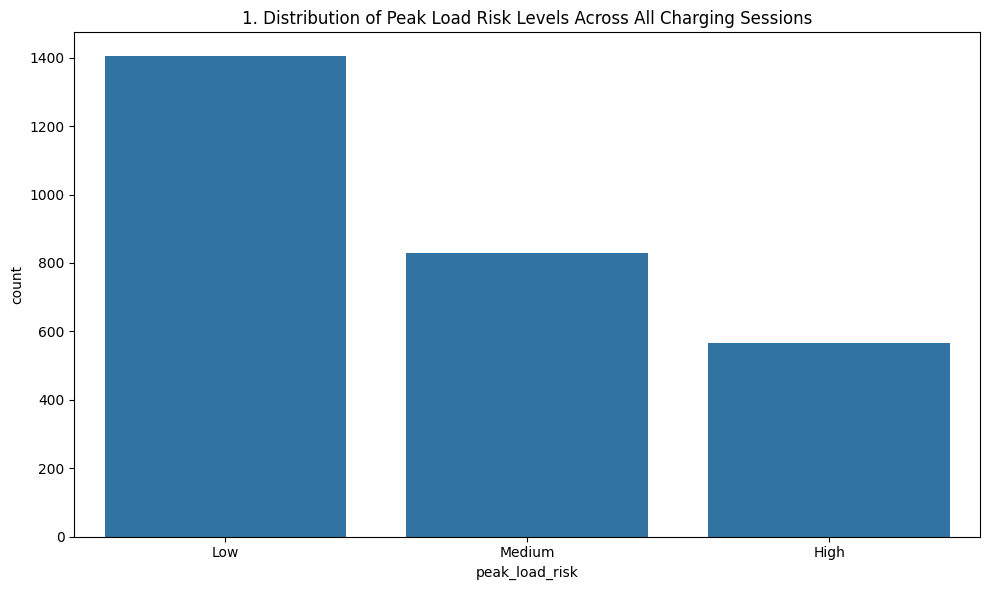

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='peak_load_risk', order=df['peak_load_risk'].value_counts().index)
plt.title(f'{plot_no}. Distribution of Peak Load Risk Levels Across All Charging Sessions')
show_fig()
plot_no += 1

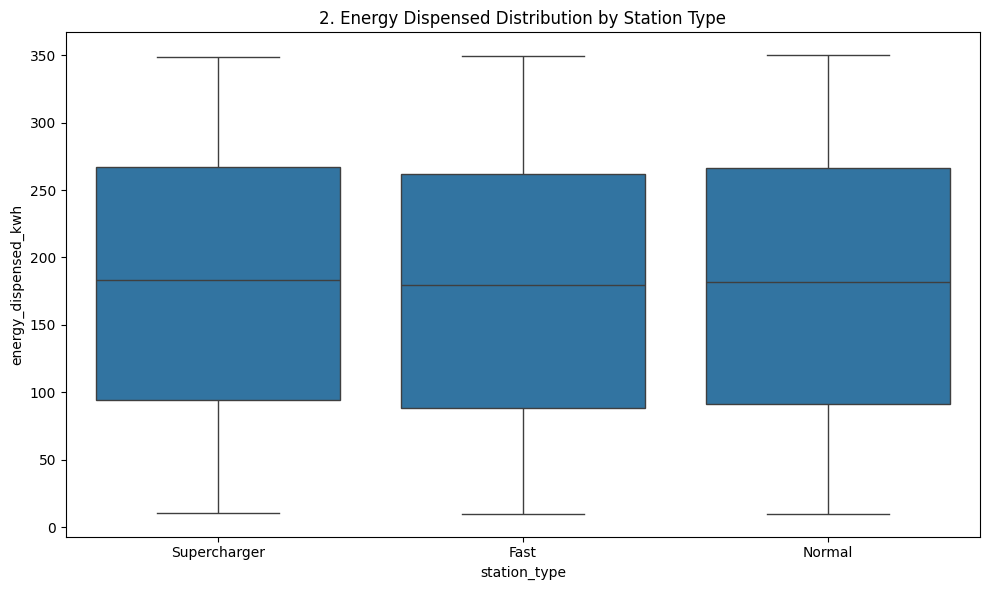

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='station_type', y='energy_dispensed_kwh')
plt.title(f'{plot_no}. Energy Dispensed Distribution by Station Type')
show_fig()
plot_no += 1

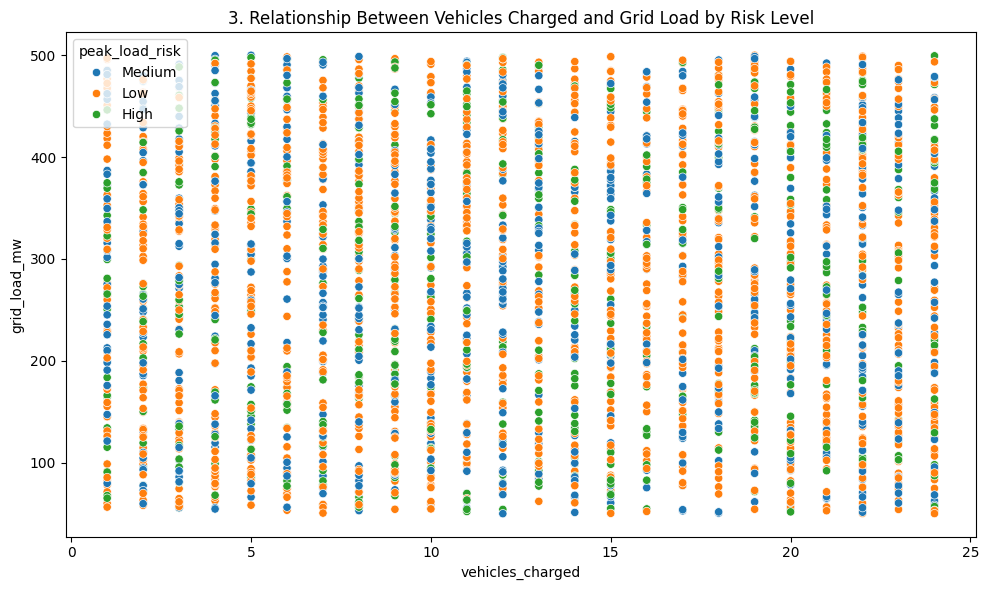

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='vehicles_charged', y='grid_load_mw', hue='peak_load_risk')
plt.title(f'{plot_no}. Relationship Between Vehicles Charged and Grid Load by Risk Level')
show_fig()
plot_no += 1

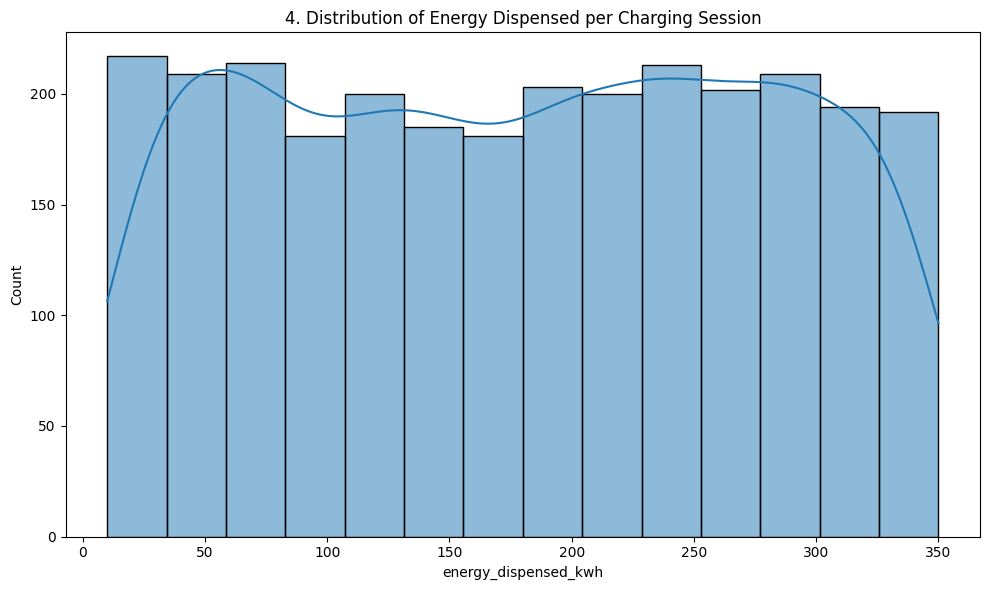

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['energy_dispensed_kwh'], kde=True)
plt.title(f'{plot_no}. Distribution of Energy Dispensed per Charging Session')
show_fig()
plot_no += 1

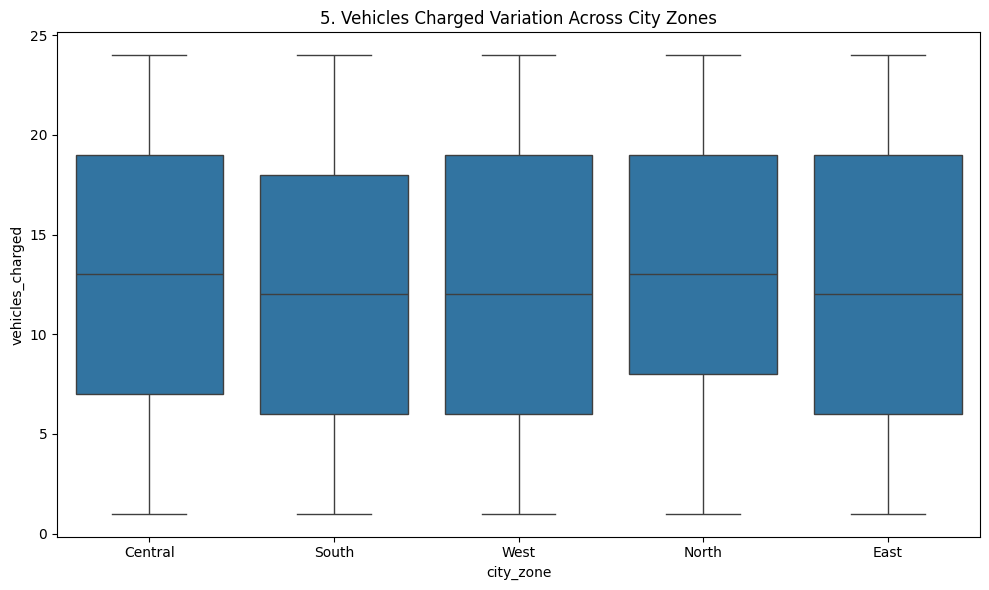

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='city_zone', y='vehicles_charged')
plt.title(f'{plot_no}. Vehicles Charged Variation Across City Zones')
show_fig()
plot_no += 1

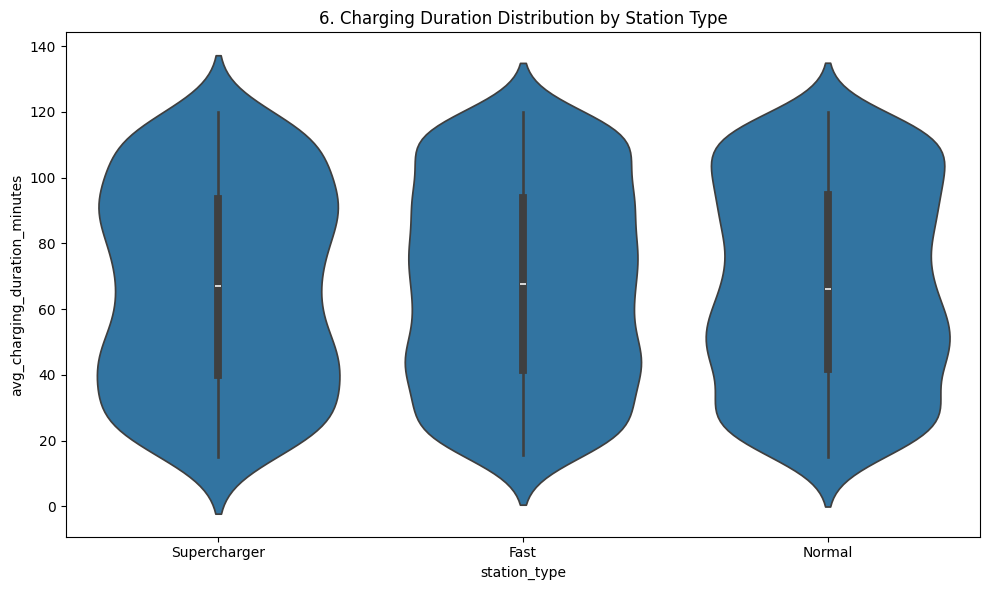

In [18]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='station_type', y='avg_charging_duration_minutes')
plt.title(f'{plot_no}. Charging Duration Distribution by Station Type')
show_fig()
plot_no += 1

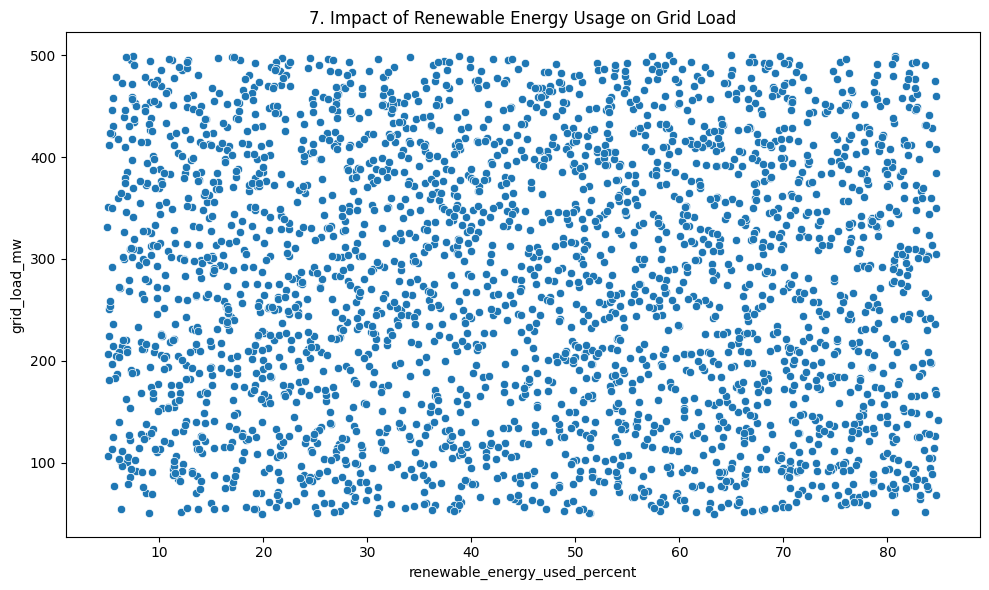

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='renewable_energy_used_percent', y='grid_load_mw')
plt.title(f'{plot_no}. Impact of Renewable Energy Usage on Grid Load')
show_fig()
plot_no += 1

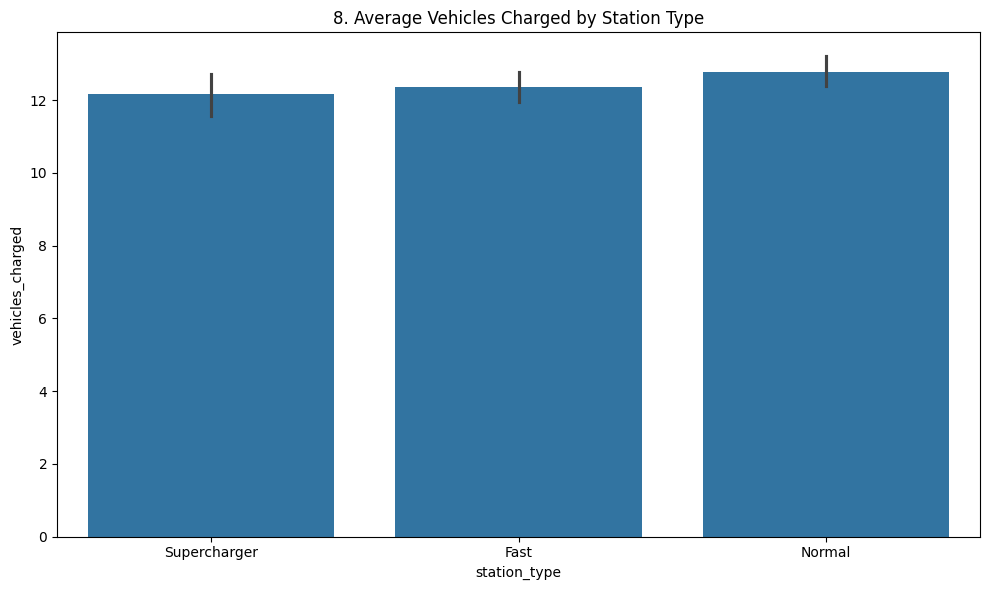

In [20]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='station_type', y='vehicles_charged', estimator=np.mean)
plt.title(f'{plot_no}. Average Vehicles Charged by Station Type')
show_fig()
plot_no += 1

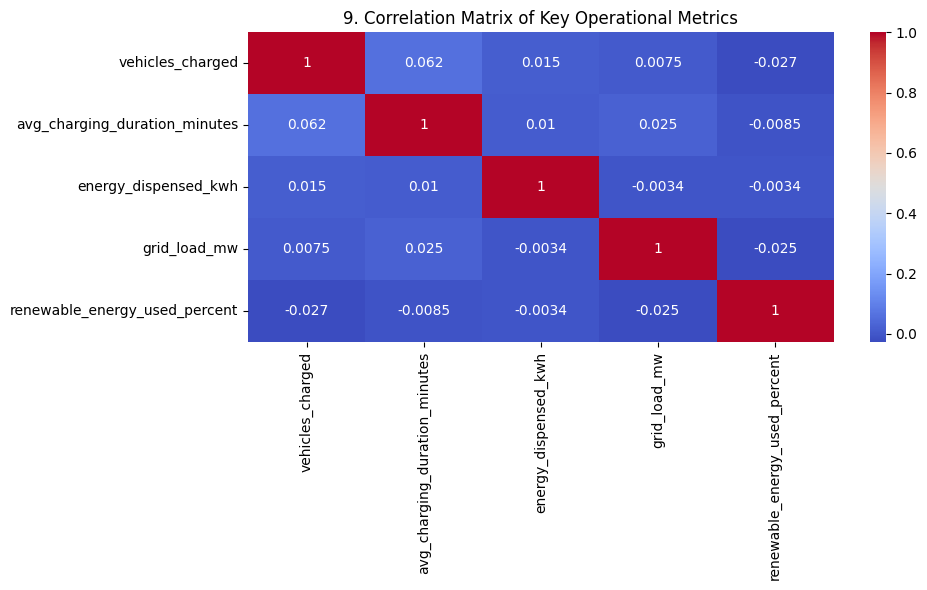

In [21]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df[['vehicles_charged','avg_charging_duration_minutes','energy_dispensed_kwh','grid_load_mw','renewable_energy_used_percent']].corr(), annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Matrix of Key Operational Metrics')
show_fig()
plot_no += 1

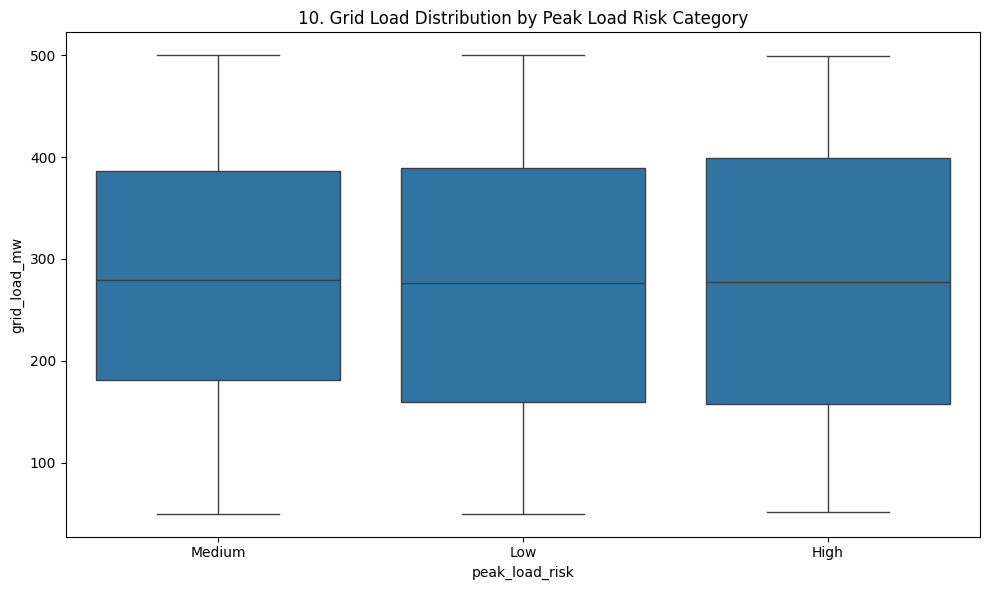

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='peak_load_risk', y='grid_load_mw')
plt.title(f'{plot_no}. Grid Load Distribution by Peak Load Risk Category')
show_fig()
plot_no += 1

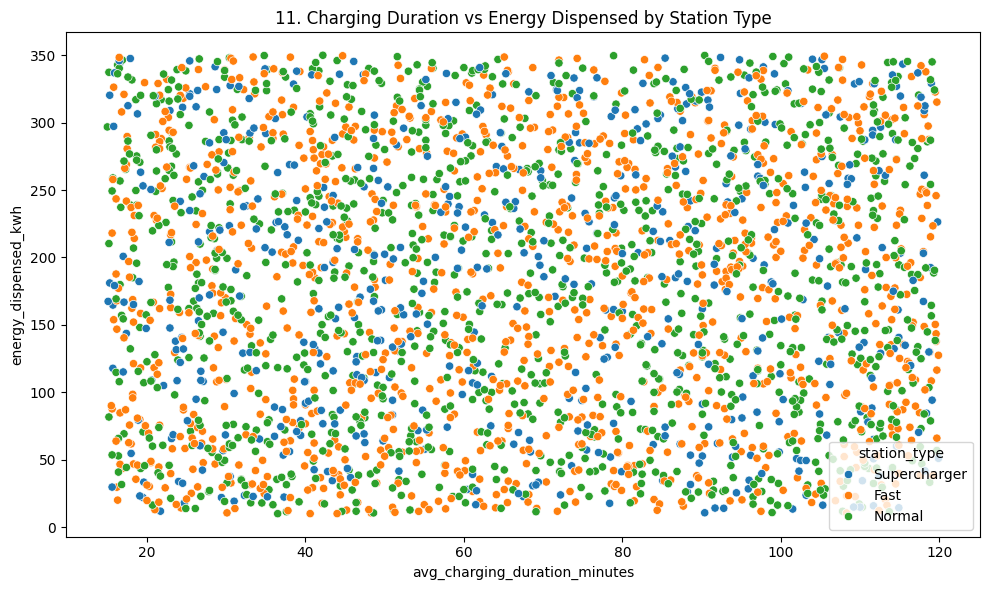

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='avg_charging_duration_minutes', y='energy_dispensed_kwh', hue='station_type')
plt.title(f'{plot_no}. Charging Duration vs Energy Dispensed by Station Type')
show_fig()
plot_no += 1

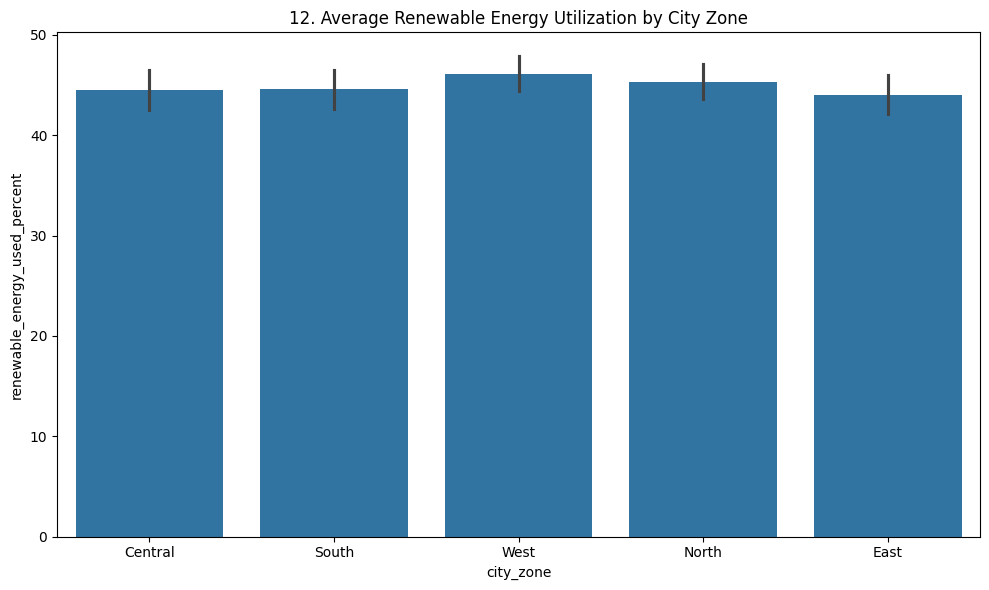

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='city_zone', y='renewable_energy_used_percent', estimator=np.mean)
plt.title(f'{plot_no}. Average Renewable Energy Utilization by City Zone')
show_fig()
plot_no += 1

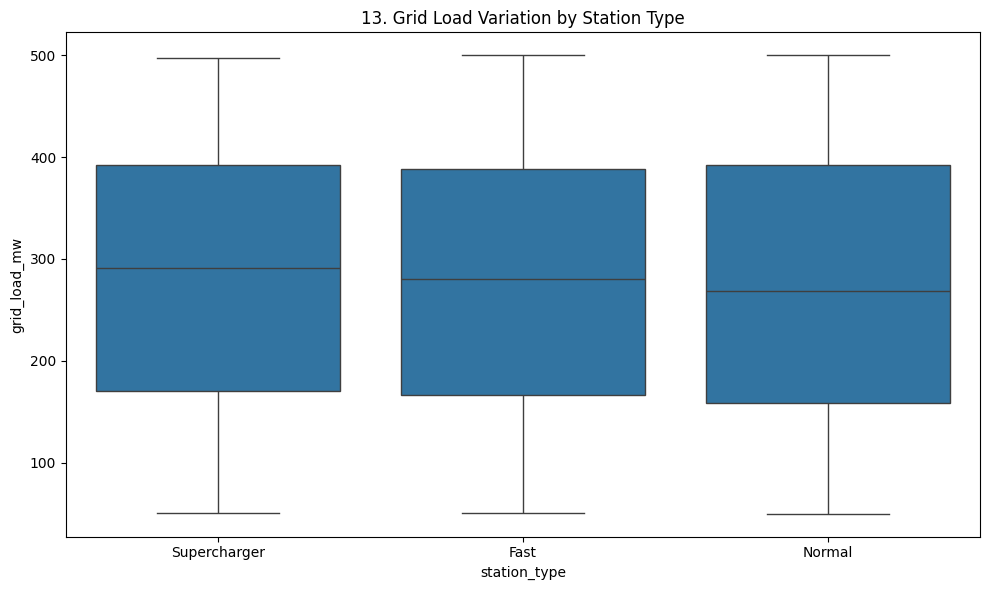

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='station_type', y='grid_load_mw')
plt.title(f'{plot_no}. Grid Load Variation by Station Type')
show_fig()
plot_no += 1

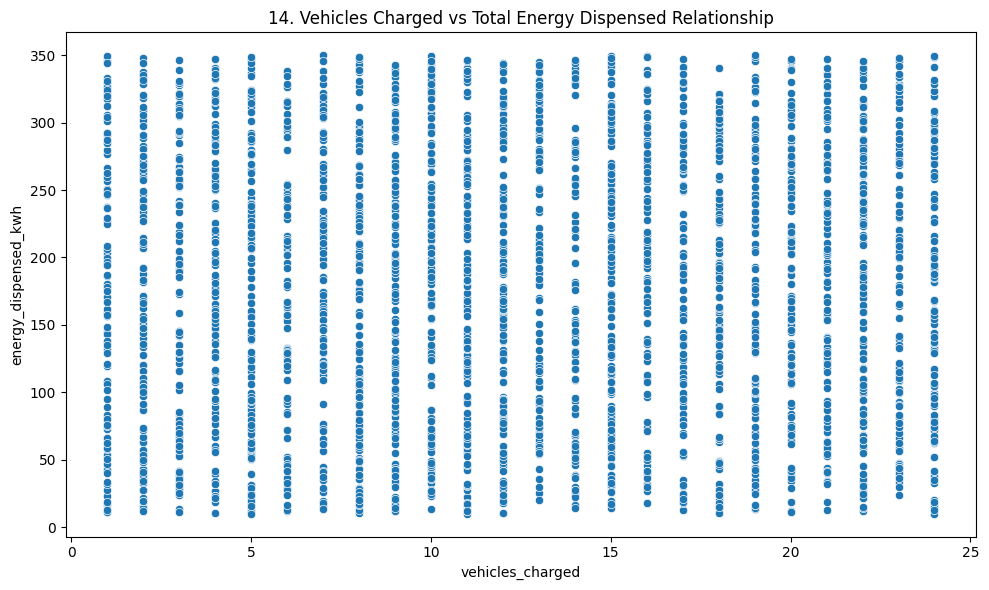

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='vehicles_charged', y='energy_dispensed_kwh')
plt.title(f'{plot_no}. Vehicles Charged vs Total Energy Dispensed Relationship')
show_fig()
plot_no += 1

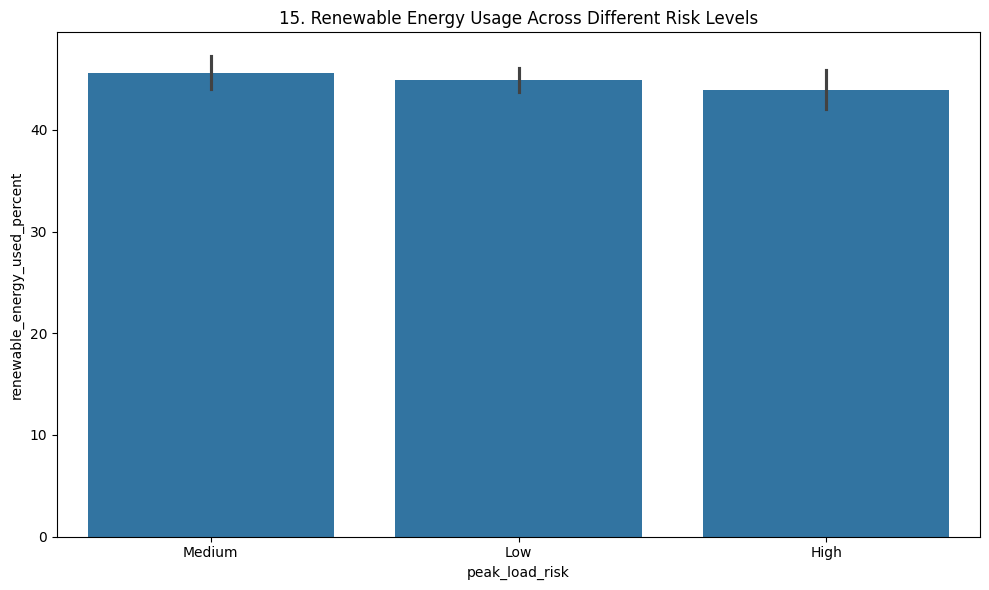

In [27]:
vfig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='peak_load_risk', y='renewable_energy_used_percent', estimator=np.mean)
plt.title(f'{plot_no}. Renewable Energy Usage Across Different Risk Levels')
show_fig()
plot_no += 1

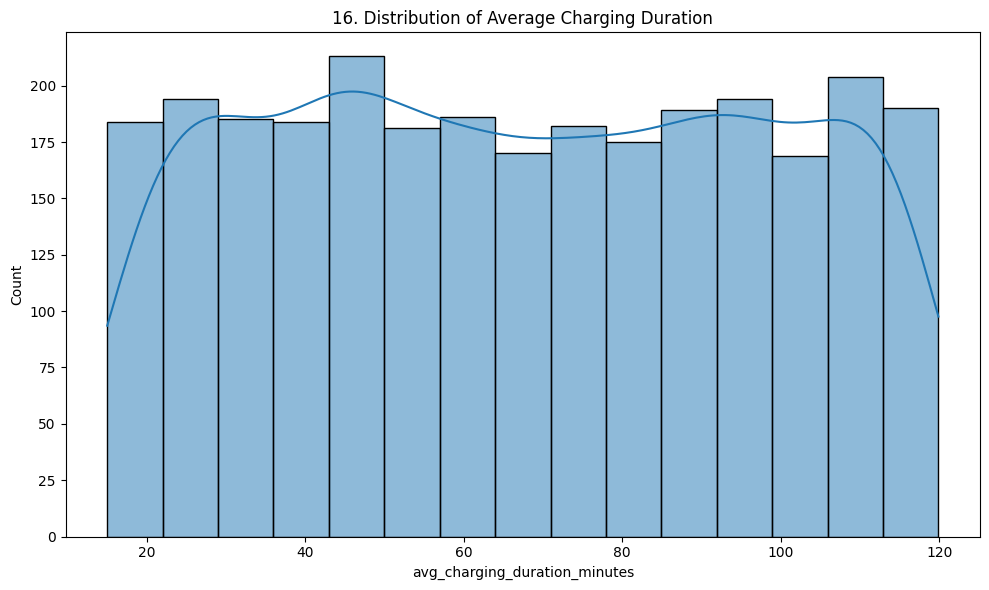

In [28]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['avg_charging_duration_minutes'], kde=True)
plt.title(f'{plot_no}. Distribution of Average Charging Duration')
show_fig()
plot_no += 1

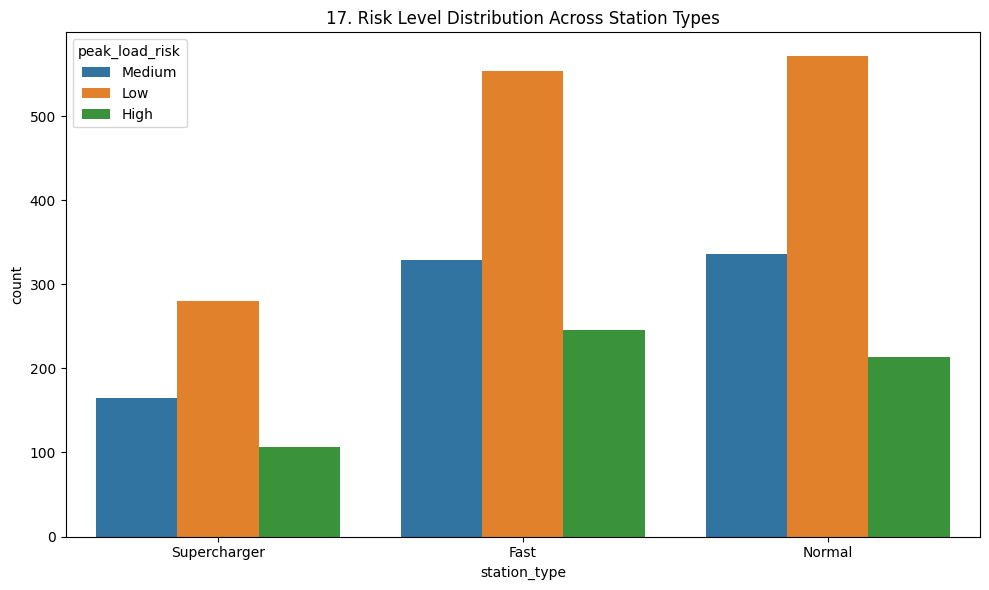

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='station_type', hue='peak_load_risk')
plt.title(f'{plot_no}. Risk Level Distribution Across Station Types')
show_fig()
plot_no += 1